# Movie Recommendation System

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_palette('viridis')

#### 1. Load data

In [2]:
movies = pd.read_csv('../data/ml-latest-small/movies.csv')
ratings = pd.read_csv('../data/ml-latest-small/ratings.csv')
links = pd.read_csv('../data/ml-latest-small/links.csv')
tags = pd.read_csv('../data/ml-latest-small/tags.csv')

In [3]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [5]:
links.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [6]:
tags.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


#### 2. Data analysis

In [7]:
n_ratings = len(ratings)
n_movies = movies['movieId'].nunique()
n_users = ratings['userId'].nunique()

print(f'Number of unique movies: {n_movies}')
print(f'Number of unique users: {n_users}')
print(f'Number of ratings: {n_ratings}')
print(f'Average number of ratings per movie: {round(n_ratings/n_movies, 2)}')
print(f'Average number of ratings per user: {round(n_ratings/n_users, 2)}')

Number of unique movies: 9742
Number of unique users: 610
Number of ratings: 100836
Average number of ratings per movie: 10.35
Average number of ratings per user: 165.3


We can see that our data is pretty dense, considering the fact that users rated 165 movies on average.\
Now let's check the distribution of ratings.

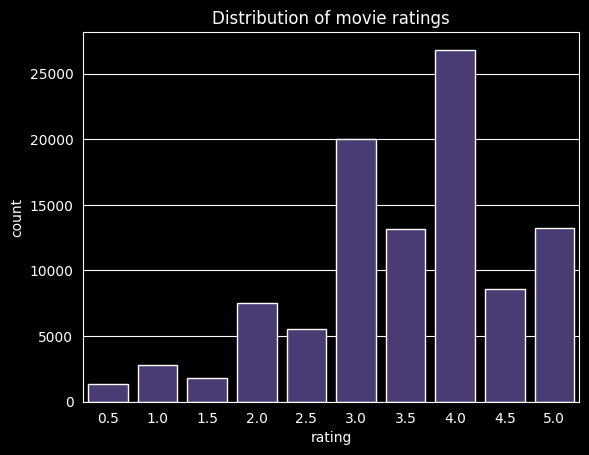

In [8]:
sns.countplot(x='rating', data=ratings)
plt.title('Distribution of movie ratings')
plt.show()

We can see that our users are quite optimistic with their ratings, but that is normal and expected for this kind of data.

In [9]:
movie_ratings = ratings.merge(movies, on='movieId')
movie_ratings.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


Let's see which movies were rated the most.

In [10]:
movie_ratings['title'].value_counts()[0:5]

title
Forrest Gump (1994)                 329
Shawshank Redemption, The (1994)    317
Pulp Fiction (1994)                 307
Silence of the Lambs, The (1991)    279
Matrix, The (1999)                  278
Name: count, dtype: int64

The most popular movies were rated the most. This makes sense.\
Now let's find out which are the best and the worst rated movie in the dataset.

In [11]:
mean_ratings = ratings.groupby('movieId')[['rating']].mean()
mean_ratings.head()

,rating
movieId,
1,3.920930
2,3.431818
3,3.259615
4,2.357143
5,3.071429


In [12]:
lowest_rated = mean_ratings['rating'].idxmin()
movies[movies['movieId'] == lowest_rated]

,movieId,title,genres
2689,3604,Gypsy (1962),Musical


In [13]:
highest_rated = mean_ratings['rating'].idxmax()
movies[movies['movieId'] == highest_rated]

,movieId,title,genres
48,53,Lamerica (1994),Adventure|Drama


In [14]:
ratings[ratings['movieId'] == highest_rated]

,userId,movieId,rating,timestamp
13368,85,53,5.0,889468268
96115,603,53,5.0,963180003


Lamerica has only two 5-star ratings so we should try another metrics, for example Bayesian average.